In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
olist_orders_dataset = pd.read_csv('olist_orders_dataset.csv')
olist_order_items_dataset = pd.read_csv('olist_order_items_dataset.csv')
olist_ordes = pd.DataFrame(olist_orders_dataset)
olist_order_items = pd.DataFrame(olist_order_items_dataset)
combined_orders_dataset = pd.merge(olist_orders_dataset, olist_order_items_dataset, on='order_id')
combined_orders_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

In [3]:
# 1. Calculate the time taken (in days) for each order to be delivered to the customer.
combined_orders_dataset['order_purchase_timestamp'] = pd.to_datetime(combined_orders_dataset['order_purchase_timestamp'])
combined_orders_dataset['order_delivered_customer_date'] = pd.to_datetime(combined_orders_dataset['order_delivered_customer_date'])
combined_orders_dataset['delivery_time_days'] = (combined_orders_dataset['order_delivered_customer_date']-combined_orders_dataset['order_purchase_timestamp']).dt.days

print(combined_orders_dataset['delivery_time_days'].min())
print(combined_orders_dataset['delivery_time_days'].max())
print("average :",combined_orders_dataset['delivery_time_days'].mean())
print("Median :",combined_orders_dataset['delivery_time_days'].median())
print(combined_orders_dataset['delivery_time_days'].std())
print(combined_orders_dataset['delivery_time_days'].describe())


0.0
209.0
average : 12.007722603361284
Median : 10.0
9.451455432008538
count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64


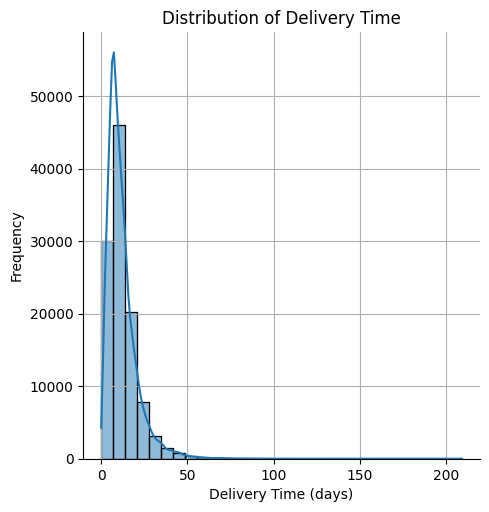

In [4]:
plt.Figure(figsize=(10, 6))
sns.displot(data=combined_orders_dataset,x='delivery_time_days',kind='hist',bins=30,kde=True)
plt.grid(True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Frequency')
plt.show()

In [5]:

# Create a revenue column (product price + freight)
combined_orders_dataset['total_revenue'] = combined_orders_dataset['price'] + combined_orders_dataset['freight_value']
# Group by seller_id and sum total revenue
seller_revenue = combined_orders_dataset.groupby('seller_id')['total_revenue'].sum().reset_index()
# Sort to get top 10 sellers
top_10_sellers = seller_revenue.sort_values(by='total_revenue', ascending=False).head(10)
print(top_10_sellers)

                             seller_id  total_revenue
857   4869f7a5dfa277a7dca6462dcf3b52b2      249640.70
1535  7c67e1448b00f6e969d365cea6b010ab      239536.44
1013  53243585a1d6dc2643021fd1853d8905      235856.68
881   4a3ca9315b744ce9f8e9374361493884      235539.96
3024  fa1c13f2614d7b5c4749cbc52fecda94      204084.73
2643  da8622b14eb17ae2831f4ac5b9dab84a      185192.32
1560  7e93a43ef30c4f03f38b393420bc753a      182754.05
192   1025f0e2d44d7041d6cf58b6550e0bfa      172860.69
1505  7a67c85e85bb2ce8582c35f2203ad736      162648.38
1824  955fee9216a65b617aa5c0531780ce60      160602.68


C:\Users\mattm\AppData\Local\Temp\ipykernel_11616\2412573600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sellers, x='seller_id', y='total_revenue', palette='magma')


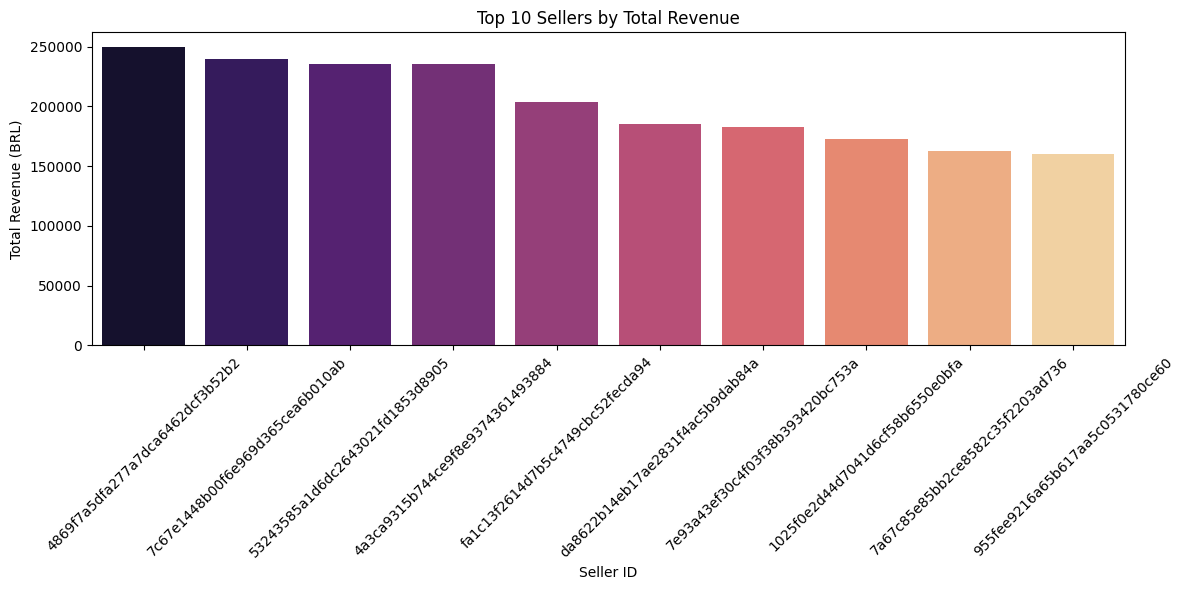

In [6]:
# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_sellers, x='seller_id', y='total_revenue', palette='magma')

plt.title('Top 10 Sellers by Total Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:

top_10_items = (combined_orders_dataset.groupby('product_id').size().reset_index(name='items_sold').sort_values(by='items_sold', ascending=False).head(10))
top_products =pd.DataFrame(top_10_items)
top_products.head(10)




,product_id,items_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,488
8613,422879e10f46682990de24d770e7f83d,484
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,388
10840,53759a2ecddad2bb87a079a1f1519f73,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,281
8051,3dd2a17168ec895c781a9191c1e95ad7,274


C:\Users\mattm\AppData\Local\Temp\ipykernel_11616\2453629679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='product_id', y='items_sold', palette='viridis')


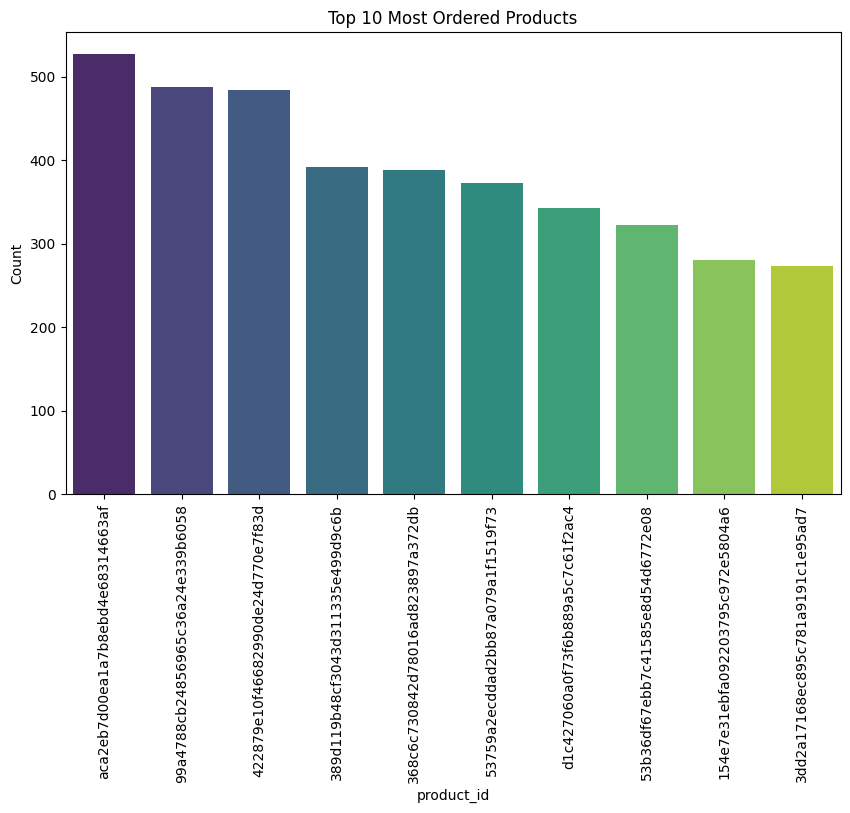

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='product_id', y='items_sold', palette='viridis')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('Top 10 Most Ordered Products')
plt.show()

In [9]:
combined_orders_dataset["order_purchase_timestamp"] = pd.to_datetime(combined_orders_dataset["order_purchase_timestamp"])
combined_orders_dataset["order_month"] = combined_orders_dataset["order_purchase_timestamp"].dt.to_period("M")
# Group by month and sum the prices
monthly_revenue = combined_orders_dataset.groupby('order_month')['price'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Total_Revenue']
# Convert 'Month' back to datetime for plotting
monthly_revenue['Month'] = monthly_revenue['Month'].dt.to_timestamp()
monthly_revenue.head(10)


,Month,Total_Revenue
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-12-01,10.90
3,2017-01-01,120312.87
4,2017-02-01,247303.02
5,2017-03-01,374344.30
6,2017-04-01,359927.23
7,2017-05-01,506071.14
8,2017-06-01,433038.60
9,2017-07-01,498031.48


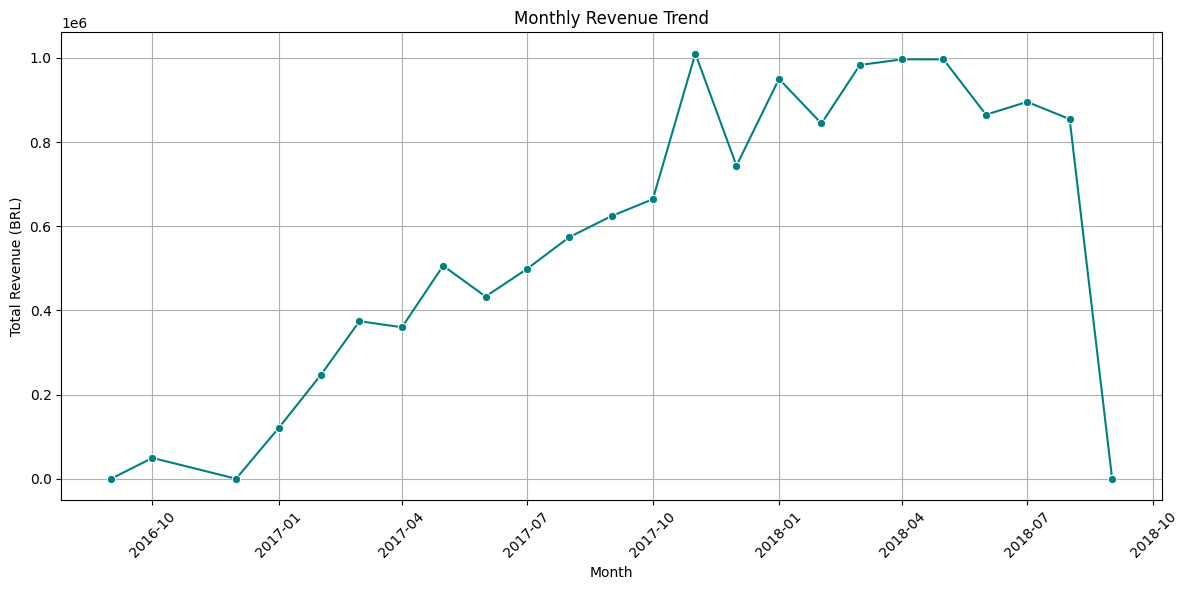

In [10]:
# Plot the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='Month', y='Total_Revenue', marker='o', color='teal')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
import pandas as pd
import plotly.express as px
import dash
import dash_bootstrap_components as dbc
from dash import dcc, html, Input, Output

# ─── 1. Load & preprocess data ────────────────────────────────────────────────
df = pd.read_csv("netflix_titles.csv")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
df["listed_in"] = df["listed_in"].fillna("")
df["main_genre"] = df["listed_in"].str.split(",").str[0].str.strip()
def parse_duration(x):
    if pd.isna(x): return None
    if "min" in x: return int(x.replace("min", "").strip())
    if "Season" in x: return int(x.replace("Seasons", "").replace("Season", "").strip())
    return None
df["duration_int"] = df["duration"].apply(parse_duration)
df["country"] = df["country"].fillna("Unknown Country")
country_mapping = {"United States": "USA", "United Kingdom": "UK"}
df["country_standardized"] = df["country"].replace(country_mapping, regex=False)
df_genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()
df['decade_added'] = df['year_added'].dropna().astype(int).floordiv(10) * 10
df['decade_added'] = df['decade_added'].astype(str) + 's'
df['decade_added'] = df['decade_added'].fillna('Unknown')

# ─── 2. Initialize Dash app with a Bootstrap theme ───────────────────────────
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.LUX])

# ─── 3. Layout ────────────────────────────────────────────────────────────────
app.layout = dbc.Container(fluid=True, children=[
    dbc.Row(dbc.Col(html.H2("📺 Netflix Analysis Dashboard"), className="my-3")),
    dbc.Row([
        dbc.Col([
            html.Label("Filter by Year Added:"),
            dcc.Dropdown(id="year_filter", options=[{"label": y, "value": y} for y in sorted(df["year_added"].dropna().unique())], placeholder="All years", clearable=True),
            html.Label("Filter by Type:"),
            dcc.Dropdown(id="type_filter", options=[{"label": t, "value": t} for t in sorted(df["type"].dropna().unique())], placeholder="All types", clearable=True),
            html.Label("Filter by Genre:"),
            dcc.Dropdown(id="genre_filter", options=[{"label": g, "value": g} for g in sorted(df_genres["genre"].dropna().unique())], placeholder="All genres", clearable=True, multi=True),
        ], width=3),
        dbc.Col([
            dbc.Row([dbc.Col(dcc.Graph(id="genre_bar"), width=6), dbc.Col(dcc.Graph(id="type_bar"), width=6)]),
            dbc.Row([dbc.Col(dcc.Graph(id="type_pie"), width=6), dbc.Col(dcc.Graph(id="timeline_line"), width=6)]),
            dbc.Row([dbc.Col(dcc.Graph(id="duration_scatter"), width=6), dbc.Col(dcc.Graph(id="geo_choropleth"), width=6)]),
        ], width=9),
    ]),
])

# ─── 4. Callbacks ─────────────────────────────────────────────────────────────
@app.callback(
    Output("genre_bar", "figure"),
    Output("type_bar", "figure"),
    Output("type_pie", "figure"),
    Output("timeline_line", "figure"),
    Output("duration_scatter", "figure"),
    Output("geo_choropleth", "figure"),
    Input("year_filter", "value"),
    Input("type_filter", "value"),
    Input("genre_filter", "value"),
)
def update_graphs(selected_year, selected_type, selected_genres):
    dff = df.copy()
    if selected_year: dff = dff[dff["year_added"] == selected_year]
    if selected_type: dff = dff[dff["type"] == selected_type]
    if selected_genres: dff = dff[dff["listed_in"].str.contains('|'.join(selected_genres), case=False)]

    genres = dff["main_genre"].value_counts().nlargest(10).reset_index()
    genres.columns = ["Genre", "Count"]
    fig_genre = px.bar(genres, x="Genre", y="Count", title="Top 10 Main Genres", template="plotly_white")

    type_counts = dff["type"].value_counts().reset_index()
    type_counts.columns = ["Type", "Count"]
    fig_type_bar = px.bar(type_counts, x="Type", y="Count", title="Movies vs TV Shows (Count)", template="plotly_white", color="Type")
    fig_type_pie = px.pie(type_counts, names="Type", values="Count", title="Movies vs TV Shows (Share)", template="plotly_white")

    timeline = dff.groupby(["year_added", "type"]).size().reset_index(name="Count")
    fig_timeline = px.line(timeline, x="year_added", y="Count", color="type", markers=True, title="Content Added Over Time by Type", template="plotly_white")

    scatter = dff.dropna(subset=["duration_int", "release_year"])
    fig_duration = px.scatter(scatter, x="release_year", y="duration_int", facet_col="type", color="type", labels={"duration_int": "Duration (min or seasons)"}, title="Duration vs Release Year", template="plotly_white")

    country_series = dff["country_standardized"].dropna().str.split(",").explode().str.strip()
    country_counts = country_series.value_counts().reset_index()
    country_counts.columns = ["country", "count"]
    fig_geo = px.choropleth(country_counts, locations="country", locationmode="country names", color="count", title="Content Production by Country", projection="natural earth", template="plotly_white")

    return fig_genre, fig_type_bar, fig_type_pie, fig_timeline, fig_duration, fig_geo

# ─── 5. Run ──────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    app.run(debug=True)

OSError: Address 'http://127.0.0.1:8050' already in use.
    Try passing a different port to run.